In [32]:
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import snapatac2 as snap
import numpy as np
import pandas as pd
import os
import scanpy.external as sce
import seaborn as sns
from sklearn.metrics import silhouette_score
import numpy as np
from scipy.stats import chi2
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict,GroupKFold,KFold
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score
from xgboost import XGBClassifier,XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
from collections import defaultdict
import glob


In [33]:
import warnings
warnings.filterwarnings("ignore")
import pyBigWig
from scipy.stats import spearmanr
import pyranges as pr


In [34]:
gr = pr.read_bed('/data2st1/junyi/output/llm0401/processed_meth/MW_AMY.CG.h.bedGraph') # Works for .bedGraph too

In [51]:
import pysam

# Open the tabix-indexed file
tbx = pysam.TabixFile("/data2st1/junyi/output/llm0401/processed_meth/MC_AMY.CG.m.bedGraph.gz")

In [58]:
# 优化技巧：批量转换
def fast_tabix_to_track(tbx, chrom, start, end):
    region = tbx.fetch(chrom, start, end)
    # 使用列表推导式减少 Python 循环开销
    data = [line.split('\t') for line in region]
    if not data:
        return np.zeros(end-start, dtype=np.float32)
    
    # 转为 numpy 进行矢量化操作，而不是在 python 循环里赋值
    starts = np.array([int(x[1]) for x in data]) - start
    ends = np.array([int(x[2]) for x in data]) - start
    vals = np.array([float(x[3]) for x in data])
    
    track = np.zeros(end-start, dtype=np.float32)
    for s, e, v in zip(starts, ends, vals):
        track[s:e] = v
    return track

In [62]:
test_region = fast_tabix_to_track(tbx, '1', 3000826, 3001018)

In [63]:
test_region

array([83.333336,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      , 

In [3]:
import pyranges as pr
import pyfaidx

# 1. 首先确保你有参考基因组文件（如 hg38.fa）
# 下载参考基因组（如果需要）:
# wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
# gunzip hg38.fa.gz

# 2. 加载参考基因组
genome = pyfaidx.Fasta('/data2st1/junyi/ref/GRCm38.p6.genome.fa')  # 或你的参考基因组文件路径

# 3. 处理你的数据框
import pandas as pd

# 示例数据
# df = pd.DataFrame({
#     'coord': ['chr10:110176088-110176188', 'chr1:1000000-1000100']
# })

# 解析坐标
def parse_coord(coord):
    """解析 chr:start-end 格式"""
    chrom, pos = coord.split(':')
    start, end = pos.split('-')
    return chrom, int(start), int(end)

# 提取序列
def get_sequence(chrom, start, end, genome):
    """从基因组获取序列"""
    # 注意：基因组坐标通常是1-based，而pyfaidx是0-based的
    # 所以 start-1 转换为0-based
    seq = genome[chrom][start-1:end].seq
    return seq

In [4]:
df_dmr = pd.read_csv('/data1st2/hannan_25/data/Nanopore_processV1/nanopore_08_differential/summary/dmrmerged_seg_anno_2tools_nofilter.csv')

In [6]:
df_dmr_selected = df_dmr[df_dmr['comparision'].str.contains('AMY') | df_dmr['comparision'].str.contains('HIP')|df_dmr['comparision'].str.contains('PFC')]
df_dmr_selected = df_dmr_selected[df_dmr['comparision'].str.contains('MC') ]

In [8]:
df_dmr_selected

,mod,motif,dmr,ifdifferent,score,num_sites,effect_size,case1_sig,case2_sig,diff.Methy,gene,comparision,tools,anno,modmotif
13210458,5hmC,CG,5hmC|CG_1:103406386-103406474,different,15.118513,5,0.060819,0.088124,0.027305,0.060819,Gm20281,MC-AMY_vs_MW-AMY,methylDMR,cdistal_88_102958922:103458922,5hmC|CG
13210459,5hmC,CG,5hmC|CG_1:103406386-103406474,different,15.118513,5,0.060819,0.088124,0.027305,0.060819,Gm37789,MC-AMY_vs_MW-AMY,methylDMR,distal_88_103224344:103722344,5hmC|CG
13210460,5hmC,CG,5hmC|CG_1:103406386-103406474,different,15.118513,5,0.060819,0.088124,0.027305,0.060819,Gm29141,MC-AMY_vs_MW-AMY,methylDMR,genebody_88_103365986:103423658,5hmC|CG
13210461,5hmC,CG,5hmC|CG_1:103406386-103406474,different,15.118513,5,0.060819,0.088124,0.027305,0.060819,Gm22034,MC-AMY_vs_MW-AMY,methylDMR,distal_88_102955548:103453548,5hmC|CG
13210462,5hmC,CG,5hmC|CG_1:103406386-103406474,different,15.118513,5,0.060819,0.088124,0.027305,0.060819,Gm18447,MC-AMY_vs_MW-AMY,methylDMR,cdistal_88_103311720:103811720,5hmC|CG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21534047,5mC,CH,5mC|CH_X:99035118-99035266,different,-70.985244,22,-0.011117,0.008720,0.019837,-0.011117,Gm14811,MC-AMY_vs_MW-AMY,merged: methylDMR,genebody_55_99005248:99040580,5mC|CH
21534048,5mC,CH,5mC|CH_X:99035118-99035266,different,-70.985244,22,-0.011117,0.008720,0.019837,-0.011117,Ophn1,MC-AMY_vs_MW-AMY,merged: methylDMR,genebody_55_99005248:99040580,5mC|CH
21534049,5mC,CH,5mC|CH_X:99035118-99035266,different,-70.985244,22,-0.011117,0.008720,0.019837,-0.011117,Gm14813,MC-AMY_vs_MW-AMY,merged: methylDMR,genebody_55_99005248:99040580,5mC|CH
21534050,5mC,CH,5mC|CH_X:99035118-99035266,different,-70.985244,22,-0.011117,0.008720,0.019837,-0.011117,Gm26000,MC-AMY_vs_MW-AMY,merged: methylDMR,genebody_55_99005248:99040580,5mC|CH


In [9]:
df_dmr_selected['chr'] = df_dmr_selected['dmr'].apply(lambda x: x.split(':')[0]).str.split('_').str[1]

In [10]:
df_dmr_selected['start'] = df_dmr_selected['dmr'].apply(lambda x: x.split(':')[1]).str.split('-').str[0].astype(int)
df_dmr_selected['end'] = df_dmr_selected['dmr'].apply(lambda x: x.split(':')[1]).str.split('-').str[1].astype(int)

In [11]:
df_dmr_selected['region'] = df_dmr_selected['comparision'].apply(lambda x: x.split('-')[-1])

In [12]:
df_dmr_selected['length'] = df_dmr_selected['end'] - df_dmr_selected['start']
df_dmr_selected['center'] = ((df_dmr_selected['end'] + df_dmr_selected['start'])/2).astype(int)


In [ ]:
# if len(df_dmr_selected) <100 then add column start_expanded and end_expanded to be center-50 and center+50
# df_dmr_selected['start_expanded'] = df_dmr_selected['start']
# df_dmr_selected['end_expanded'] = df_dmr_selected['end']
# df_dmr_selected.loc[df_dmr_selected['length']<100, 'start_expanded'] = df_dmr_selected.loc[df_dmr_selected['length']<100, 'center'] - 50
# df_dmr_selected.loc[df_dmr_selected['length']<100, 'end_expanded'] = df_dmr_selected.loc[df_dmr_selected['length']<100, 'center'] + 50

In [17]:
df_dmr_selected['start_expanded'] = df_dmr_selected['start']
df_dmr_selected['end_expanded'] = df_dmr_selected['end']
df_dmr_selected.loc[df_dmr_selected['length']<100, 'start_expanded'] = df_dmr_selected.loc[df_dmr_selected['length']<1024, 'center'] - 512
df_dmr_selected.loc[df_dmr_selected['length']<100, 'end_expanded'] = df_dmr_selected.loc[df_dmr_selected['length']<1024, 'center'] + 512

In [19]:
df_dmr_selected_unique = df_dmr_selected.drop_duplicates(subset=['dmr','comparision','modmotif'])

In [22]:
df_dmr_selected_unique.to_csv('output/dmr_selected_unique.csv',index=False)

In [23]:
df_dmr_selected_unique

,mod,motif,dmr,ifdifferent,score,num_sites,effect_size,case1_sig,case2_sig,diff.Methy,...,anno,modmotif,chr,start,end,region,length,center,start_expanded,end_expanded
13210458,5hmC,CG,5hmC|CG_1:103406386-103406474,different,15.118513,5,0.060819,0.088124,0.027305,0.060819,...,cdistal_88_102958922:103458922,5hmC|CG,1,103406386,103406474,AMY,88,103406430,103405918,103406942
13210467,5hmC,CG,5hmC|CG_1:104583346-104583433,different,-26.034180,6,-0.088450,0.094820,0.183270,-0.088450,...,cdistal_87_104321120:104821120,5hmC|CG,1,104583346,104583433,AMY,87,104583389,104582877,104583901
13210490,5hmC,CG,5hmC|CG_1:105226254-105226442,different,-25.957915,8,-0.067298,0.032287,0.099585,-0.067298,...,distal_188_105069138:105382259,5hmC|CG,1,105226254,105226442,AMY,188,105226348,105226254,105226442
13210527,5hmC,CG,5hmC|CG_1:105811140-105811201,different,-25.503771,6,-0.117144,0.200579,0.317723,-0.117144,...,distal_61_105490251:105979349,5hmC|CG,1,105811140,105811201,AMY,61,105811170,105810658,105811682
13210564,5hmC,CG,5hmC|CG_1:10695071-10695236,different,41.361860,12,0.088860,0.210805,0.121945,0.088860,...,cdistal_165_10467932:10967932,5hmC|CG,1,10695071,10695236,AMY,165,10695153,10695071,10695236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21533325,5mC,CH,5mC|CH_X:93052888-93053236,different,134.530909,44,0.013210,0.015345,0.002134,0.013210,...,distal_102_92664901:93162901,5mC|CH,X,93052888,93053236,PFC,348,93053062,93052888,93053236
21533519,5mC,CH,5mC|CH_X:93307956-93309782,different,678.016103,179,0.015443,0.024606,0.009163,0.015443,...,cdistal_472_93028853:93528853,5mC|CH,X,93307956,93309782,HIP,1826,93308869,93307956,93309782
21533794,5mC,CH,5mC|CH_X:94971193-94971995,different,80.192225,23,0.013284,0.014595,0.001311,0.013284,...,distal_70_94944871:95420317,5mC|CH,X,94971193,94971995,AMY,802,94971594,94971193,94971995
21533979,5mC,CH,5mC|CH_X:98151991-98152650,different,658.417314,199,0.015146,0.023755,0.008608,0.015146,...,distal_513_98042375:98540375,5mC|CH,X,98151991,98152650,AMY,659,98152320,98151991,98152650


In [15]:
region = 'PFC'
typedict = {'5mC': 'm', '5hmC': 'h'}
condition = 'MW'
motif = 'CG'
methtype = '5hmC'


In [27]:
glob.glob(f'/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC*-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig')

['/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC21D-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig',
 '/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC39B-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig',
 '/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC33A-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig']

In [28]:
glob.glob(f'/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW*-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig')

['/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW51E-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig',
 '/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW26B-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig',
 '/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW34C-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig']

In [29]:
glob.glob(f'/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW*-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig')

['/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW51E-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig',
 '/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW34C-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig',
 '/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW26B-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig']

In [31]:
glob.glob(f'/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC*-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig')

['/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC39B-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig',
 '/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC50C-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig',
 '/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC21D-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig']

In [17]:
sum_sigmethylation = []
sum_sigatac = []
sum_names = []
for region in ['AMY', 'HIP', 'PFC']:
    for condition in ['MW', 'MC']:
        for methtype in ['5mC', '5hmC']:
            meth_tracks = glob.glob(f'/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/*{condition}*{region}.6mA_5mC5hmC.{motif}.pileup.{typedict[methtype]}.bigwig')
            # 打开 BigWig 文件
            methlist = []
            for meth_track in meth_tracks:
                try:
                    meth = pyBigWig.open(meth_track)
                    methlist.append(meth)
                except Exception as e:
                    print(f"Error opening {meth_track}: {e}")

            atac = pyBigWig.open(f"/data2st2/junyi/output/atac1112/tobiasbam/BULK/corrected/{region}_{condition}_track.bw")
            df_hip=df_dmr_selected[df_dmr_selected['region']==region]
            # for each row in df_hip, extract the mean signal from the BigWig file for the corresponding region
            signals = []
            corrs = []
            for index, row in df_hip.iterrows():
                try:
                    chrom = row['chr']
                    start = row['start_expanded']
                    end = row['end_expanded']


                    # get the average signal from the BigWig file for the region
                    meth_signals = []
                    for meth in methlist:
                        meth_tmp = meth.values(chrom, start, end)
                        meth_tmp_sig = np.nan_to_num(meth_tmp)
                        meth_signals.append(meth_tmp_sig)
                    meth_signal = np.mean(meth_signals,axis=0)


                    atac_signal = atac.values("chr"+chrom, start, end)

                    #fill nan with 0
                    atac_signal = np.nan_to_num(atac_signal)

                    seq = get_sequence("chr"+chrom, start, end-1, genome)
                            # REMOVE the position that the position is not C
                    seq_array = np.array(list(seq.upper()))
                    is_c = (seq_array == 'C')
                    is_g = (seq_array == 'G')
                    is_cg = is_c | is_g

                    meth_signal_clean = meth_signal[is_cg]
                    atac_signal_clean = atac_signal[is_cg]

                    sum_sigmethylation.append(meth_signal_clean.mean())
                    sum_sigatac.append(atac_signal.mean())
                    sum_names.append(f"{region}_{condition}_{methtype}")

                    # calculate the correlation between meth_signal and atac_signal
                    if len(meth_signal_clean) > 1 and len(atac_signal_clean) > 1:
                        corr, _ = pearsonr(meth_signal_clean, atac_signal_clean)
                    else:
                        corr = np.nan
                except Exception as e:
                    corr = np.nan
                corrs.append(corr)
            plt.hist(corrs, bins=50,alpha=0.5,label=f'{region}_{condition}_{methtype}')
            plt.legend()
        plt.savefig(f'figures/{region}_{condition}_{methtype}_correlation_histogram.png')
        plt.clf()
        print(f"{region}_{condition}_{methtype}: mean corr = {np.nanmean(corrs):.4f}, median corr = {np.nanmedian(corrs):.4f}")


AMY_MW_5hmC: mean corr = 0.0041, median corr = 0.0044
AMY_MC_5hmC: mean corr = 0.0008, median corr = 0.0006
HIP_MW_5hmC: mean corr = -0.0028, median corr = -0.0052
HIP_MC_5hmC: mean corr = -0.0031, median corr = -0.0048
PFC_MW_5hmC: mean corr = -0.0014, median corr = -0.0026
PFC_MC_5hmC: mean corr = -0.0014, median corr = -0.0020


<Figure size 640x480 with 0 Axes>

In [ ]:
import pyBigWig
import numpy as np
from scipy.stats import pearsonr, spearmanr

def calculate_chrom_correlation(bw_file1, bw_file2, chrom1, chrom2, bin_size=1000, corr_type='pearson'):
    """
    计算两个染色体 BigWig 信号在给定 bin 大小下的相关性
    
    参数：
    bw_file1, bw_file2: BigWig 文件路径
    chrom1, chrom2: 染色体名称，如 'chr1', 'chr2'
    bin_size: bin 大小（bp），默认 1000
    corr_type: 相关性类型，'pearson' 或 'spearman'
    """
    # 1. 打开 BigWig 文件
    bw1 = pyBigWig.open(bw_file1)
    bw2 = pyBigWig.open(bw_file2)
    
    # 2. 获取染色体长度
    chrom_len1 = bw1.chroms()[chrom1]
    chrom_len2 = bw2.chroms()[chrom2]
    
    # 3. 计算 bin 数量（取两者中较短的长度）
    n_bins = min(chrom_len1, chrom_len2) // bin_size
    
    # 4. 创建 bin 边界
    bins = [(i * bin_size, (i + 1) * bin_size) for i in range(n_bins)]
    
    # 5. 提取每个 bin 的信号（平均值）
    signal1 = []
    signal2 = []
    for start, end in bins:
        # 注意：确保 end 不超过染色体长度
        end = min(end, chrom_len1, chrom_len2)
        s1 = bw1.stats(chrom1, start, end)[0] or 0
        s2 = bw2.stats(chrom2, start, end)[0] or 0
        signal1.append(s1)
        signal2.append(s2)
    
    # 6. 计算相关性
    signal1 = np.array(signal1)
    signal2 = np.array(signal2)
    
    if corr_type == 'pearson':
        corr, pval = pearsonr(signal1, signal2)
    elif corr_type == 'spearman':
        corr, pval = spearmanr(signal1, signal2)
    else:
        raise ValueError("corr_type 必须是 'pearson' 或 'spearman'")
    
    bw1.close()
    bw2.close()
    
    return corr, pval, n_bins, signal1, signal2

# 使用示例
bw1_path = "your_file1.bw"
bw2_path = "your_file2.bw"
chrom1 = "chr1"
chrom2 = "chr2"

corr, pval, n_bins, s1, s2 = calculate_chrom_correlation(
    bw1_path, bw2_path, chrom1, chrom2, bin_size=1000, corr_type='pearson'
)
print(f"染色体 {chrom1} 与 {chrom2} 在 {n_bins} 个 bins 下的 Pearson 相关系数: {corr:.4f}, p-value: {pval:.4e}")

In [19]:
corr_df = pd.DataFrame({
    'sample': sum_names,
    'mean_methylation': sum_sigmethylation,
    'mean_atac': sum_sigatac
})

In [ ]:
import pyBigWig
from scipy.stats import spearmanr

for region in ['AMY','HIP','PFC']:
    for condition in ['MW', 'MC']:
        files = glob.glob(f'/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/*{condition}*{region}.6mA_5mC5hmC.CG.pileup.m.bigwig')
        for f in files:
            print(f)
            # 打开 BigWig 文件
            meth = pyBigWig.open(f)
            meth1 = f.replace('.m.bigwig', '.h.bigwig')
            meth2 = pyBigWig.open(meth1)
            df_hip=df_dmr_selected[df_dmr_selected['region']==region]
            df_hip=df_hip[df_hip['motif']=='CG']
            df_hip=df_hip[df_hip['comparision'].str.contains('MC')]
            # for each row in df_hip, extract the mean signal from the BigWig file for the corresponding region
            corrs = []
            seqs = []
            sig1 = []
            sig2 = []
            for index, row in df_hip.iterrows():
                try:
                    chrom = row['chr']
                    start = row['start_expanded']
                    end = row['end_expanded']
                    meth_signal = meth.values(chrom, start, end)
                    meth2_signal = meth2.values(chrom, start, end)
                    

                    #fill nan with 0
                    meth_signal = np.nan_to_num(meth_signal)
                    meth2_signal = np.nan_to_num(meth2_signal)

                    sig1.append(meth_signal)
                    sig2.append(meth2_signal)

                    seq = genome["chr"+chrom][start:end].seq
                    seqs.append(seq)


                    # REMOVE the position that the position is not C
                    seq_array = np.array(list(seq.upper()))
                    is_c = (seq_array == 'C')
                    is_g = (seq_array == 'G')
                    is_cg = is_c | is_g

                    meth_signal_clean = meth_signal[is_cg]
                    meth2_signal_clean = meth2_signal[is_cg]

                    # calculate the correlation between meth_signal and meth2_signal
                    if len(meth_signal_clean) > 1 and len(meth2_signal_clean) > 1:
                        if sum(meth_signal_clean) > 0 and sum(meth2_signal_clean) > 0:
                            corr, _ = pearsonr(meth_signal_clean, meth2_signal_clean)
                    else:
                        corr = 0
                except Exception as e:
                    corr = 0
                corrs.append(corr)
            plt.hist(corrs, bins=50)
            plt.savefig(f'figures/{os.path.basename(f)[:9]}_5mC_5hmC_correlation_histogram.png')
            plt.clf()

/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW51E-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW26B-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW34C-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC21D-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC39B-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MC33A-AMY.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW51E-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW34C-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/hannan_25/data/Nanopore_processV1/nanopore_06_distribution/MW26B-HIP.6mA_5mC5hmC.CG.pileup.m.bigwig
/data1st2/

<Figure size 640x480 with 0 Axes>

In [342]:
meth_signal_clean

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        80.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
         0.        , 100.        ,  28.57143021,   0.        ,
         0.        ,   0.        ,   0.        , 100.        ,
        87.5       ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ])

In [336]:
meth2_signal_clean

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , 50.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       28.57143021,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  6.25      ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ])

In [343]:
DF_CG=pd.DataFrame({
    'seq': seq_array,
    'meth_signal': meth_signal,
    'meth2_signal': meth2_signal
})

In [347]:
DF_CG

,seq,meth_signal,meth2_signal
0,C,0.0,0.0
1,T,0.0,0.0
2,C,0.0,0.0
3,C,0.0,0.0
4,A,0.0,0.0
...,...,...,...
95,T,0.0,0.0
96,C,0.0,0.0
97,C,0.0,0.0
98,T,0.0,0.0


In [346]:
pearsonr(meth_signal_clean, meth2_signal_clean)

PearsonRResult(statistic=0.006037336125656931, pvalue=0.9638029603314087)

In [115]:
seq_array = np.array(list(seq.upper()))
is_c = (seq_array == 'C')

meth_signal_clean = meth_signal[is_c]
#open_signal_clean = open_signal[is_c]


In [321]:
DF_CG

,seq,meth_signal,meth2_signal
0,C,48.795181,1.204819
1,G,0.000000,1.265823
2,C,0.000000,0.000000
3,A,0.000000,0.000000
4,C,0.000000,0.000000
...,...,...,...
95,C,0.000000,0.000000
96,T,0.000000,0.000000
97,G,0.000000,0.000000
98,G,0.000000,0.000000


In [291]:
seq = genome["chr"+chrom][start:end].seq

In [292]:
seq_array = np.array(list(seq.upper()))
seq_array


array(['C', 'G', 'C', 'A', 'C', 'A', 'G', 'A', 'T', 'T', 'T', 'G', 'C',
       'A', 'T', 'A', 'A', 'T', 'G', 'A', 'G', 'G', 'C', 'T', 'C', 'A',
       'C', 'A', 'G', 'A', 'G', 'A', 'T', 'G', 'C', 'A', 'A', 'A', 'T',
       'T', 'T', 'G', 'C', 'A', 'G', 'A', 'A', 'A', 'C', 'T', 'T', 'T',
       'A', 'C', 'A', 'A', 'T', 'G', 'C', 'A', 'A', 'C', 'G', 'C', 'T',
       'C', 'A', 'G', 'A', 'T', 'T', 'T', 'G', 'C', 'A', 'C', 'A', 'C',
       'T', 'G', 'A', 'G', 'G', 'C', 'G', 'C', 'T', 'C', 'A', 'G', 'A',
       'T', 'G', 'C', 'T', 'C', 'T', 'G', 'G', 'C'], dtype='<U1')

In [294]:
is_c = (seq_array == 'C')

meth_signal_clean = meth_signal[is_c]
meth2_signal_clean = meth2_signal[is_c]


In [297]:
meth_signal

array([48.79518127,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , 29.89130402, 15.15151596,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [296]:
meth_signal_clean

array([48.79518127,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , 29.89130402,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        , 60.1895752 ,  0.        ,
        0.        ,  0.        ,  0.        , 33.60655594])

In [295]:
meth2_signal_clean

array([1.2048192 , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 5.97826099, 0.        , 0.        ,
       0.        , 0.        , 0.        , 2.8436017 , 0.        ,
       0.        , 0.        , 0.        , 0.81967211])

In [101]:
def group_chromosomes(df_merged_region):
    chr_counts = df_merged_region['chr'].value_counts()

    # 2) 设定目标 group size（≈ 最大 chr）
    target_size = chr_counts.max()

    # 3) 初始化
    groups = defaultdict(list)      # group_id -> list of chrs
    group_sizes = defaultdict(int)  # group_id -> total region count

    # 4) 贪心分配（chr 从大到小）
    for chr_name, count in chr_counts.sort_values(ascending=False).items():
        # 找当前 size 最小的 group
        if len(group_sizes) == 0:
            gid = 0
        else:
            gid = min(group_sizes, key=lambda k: group_sizes[k])

        # 如果这个 group 已经接近 target，新建一个
        if group_sizes[gid] + count > target_size * 1.1:
            gid = len(group_sizes)

        groups[gid].append(chr_name)
        group_sizes[gid] += count

    chrGroup = df_merged_region['chr'].map(
        {chr_name: gid for gid, chr_list in groups.items() for chr_name in chr_list}
    ).values
    return chrGroup

In [103]:
# data preparation
pefromdict = {}

for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        
        df_region_mod = annodict[mod][annodict[mod]['Region'] == region].copy()
        df_region_mod_frac = pd.DataFrame()
        for condition in ['MC','MW']:
            df_tmp_frac = pd.read_csv(
                f'/data2st1/junyi/output/atac1112/subset/dmr_region_nt/{region}_{mod}_{condition}_celltype_fraction.csv',
                index_col=0
            )
            # remove _MC and MW suffix from columns
            df_tmp_frac.columns = [col.replace('_MC', '').replace('_MW', '') for col in df_tmp_frac.columns]
            df_tmp_frac['condition'] = condition
            df_region_mod_frac = pd.concat([df_region_mod_frac, df_tmp_frac], axis=0)
        df_region_mod['extended_dmr'] = (
            'chr' + df_region_mod['chr'].astype(str) + ':' +
            df_region_mod['start_expanded'].astype(str) + '-' +
            df_region_mod['end_expanded'].astype(str)
        )
        df_region_mod['id'] = df_region_mod.index
        df_region_mod = df_region_mod.set_index('extended_dmr')

        df_merged_region = pd.merge(
            df_region_mod,
            df_region_mod_frac,
            left_index=True,
            right_index=True,
            how='inner'
        )

        # binary label: 1 = hyper (diff.Methy > 0), 0 = hypo
        df_merged_region['effect_binary'] = (df_merged_region['diff.Methy'] > 0).astype(int)
        df_merged_region['effect_size'] = df_merged_region['effect_size']
        df_merged_region['pct_meth'] = df_merged_region['case1_sig']
        df_merged_region.loc[df_merged_region.condition=='MW', 'pct_meth'] = df_merged_region.loc[df_merged_region.condition=='MW', 'case2_sig']
        df_merged_region['condition_binary'] = (df_merged_region['condition']=='MC').astype(int)
        df_merged_region.drop_duplicates(subset=['chr', 'start','end','condition_binary'], inplace=True)
        df_merged_region['chr']=df_merged_region['chr'].astype(str)
        df_merged_region['chrgroup'] = group_chromosomes(df_merged_region)
        feature_cols = ['Astrocyte', 'Epen', 'GABA', 'Glut', 'Microglia', 'OPC', 'Oligo', 'Vascular','condition_binary']
        X = df_merged_region.loc[:, feature_cols].values.astype(np.float32)
        #y = df_merged_region['effect_binary'].values.astype(int)
        y = df_merged_region['pct_meth'].values
        chr = df_merged_region['chr'].values.astype(str)
        
        
        pefromdict[f'{region}_{mod}'] = {
            'X': X,
            'y': y,
            'chr': chr,
            'chrgroup': df_merged_region['chrgroup'].values,
            'y_reg': df_merged_region['effect_size'].values.astype(np.float32),
            'feature_cols': feature_cols,
            'df': df_merged_region
        }


In [ ]:
# map chr to group ids


In [110]:
df_merged_region.groupby('chr')['diff.Methy'].mean()

chr
1     0.000275
10   -0.012183
11   -0.016394
12   -0.005000
13   -0.015315
14    0.001563
15   -0.007246
16   -0.006361
17   -0.037921
18   -0.017827
19   -0.016556
2    -0.013175
3    -0.012258
4    -0.008502
5    -0.000533
6     0.016658
7    -0.009988
8    -0.003669
9    -0.002720
X     0.056710
Y     0.130367
Name: diff.Methy, dtype: float64

In [107]:
# deconvolution
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:
        
        chr = pefromdict[f'{region}_{mod}']['chr']
        gkf = GroupKFold(n_splits=5, shuffle=True, random_state=42)
        #cv = KFold(n_splits=10, shuffle=True, random_state=42)
        #gss = GroupShuffleSplit(n_splits=10, test_size=0.1, random_state=42)

        # XGBoost regressor
        model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=8,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_lambda=1.0,
            # min_child_weight=1.0,
            # gamma=0.0,
            # objective='binary:logistic',
            # eval_metric='logloss',
            # tree_method='hist',     # fast on GPU; change to 'hist' if you have CPU
            n_jobs=-1,
            random_state=42
        )

        X = pefromdict[f'{region}_{mod}']['X']

        # MUST be continuous (e.g., diff.Methy)
        y = pefromdict[f'{region}_{mod}']['y'].astype(np.float32)


        # out-of-fold predictions (no leakage)
        #y_pred_oof = cross_val_predict(model, X, y, cv=cv, method="predict")
        y_pred_oof = cross_val_predict(
            model,
            X,
            y,
            cv=gkf,
            groups=chr,
            method="predict"
        )
        #y_pred_oof = cross_val_predict(model, X, y, cv=gss, groups=chr, method="predict")

        r2 = r2_score(y, y_pred_oof)
        rmse = root_mean_squared_error(y, y_pred_oof)
        mae = mean_absolute_error(y, y_pred_oof)

        if np.std(y) > 1e-12 and np.std(y_pred_oof) > 1e-12:
            r, p = pearsonr(y, y_pred_oof)
        else:
            r, p = np.nan, np.nan

        print(region, mod)
        print("R2:", r2)
        print("Pearson r:", r, "p:", p)
        print("RMSE:", rmse)
        print("MAE:", mae)
        print("-" * 60)

        # fit final model on all data
        model.fit(X, y)

        # in-sample predictions
        y_pred = model.predict(X)

        # update dict (keep existing df/feature_cols if already stored)
        pefromdict[f'{region}_{mod}'].update({
            'model_reg': model,
            'y_pred_oof_reg': y_pred_oof,
            'y_pred_reg': y_pred
        })


HIP 5mC
R2: -0.12010979652404785
Pearson r: 0.23348705 p: 1.8880569146653751e-53
RMSE: 0.1313609629869461
MAE: 0.10649266093969345
------------------------------------------------------------
HIP 5hmC
R2: -0.057790517807006836
Pearson r: 0.16274467 p: 7.182041827811732e-30
RMSE: 0.11011158674955368
MAE: 0.07979516685009003
------------------------------------------------------------
AMY 5mC
R2: 0.036139607429504395
Pearson r: 0.24922681 p: 3.4713668322840627e-153
RMSE: 0.15618041157722473
MAE: 0.1219044029712677
------------------------------------------------------------
AMY 5hmC
R2: 0.05235159397125244
Pearson r: 0.2582823 p: 3.150122833930497e-170
RMSE: 0.1140083521604538
MAE: 0.08693691343069077
------------------------------------------------------------
PFC 5mC
R2: 0.017051756381988525
Pearson r: 0.3340158 p: 1.2318933762538335e-169
RMSE: 0.13245321810245514
MAE: 0.10123074799776077
------------------------------------------------------------
PFC 5hmC
R2: -0.09699726104736328
Pea

In [32]:
pearsonr(y, y_pred)

PearsonRResult(statistic=0.9983884, pvalue=0.0)

In [108]:
# deconvolution
for region in ['HIP', 'AMY', 'PFC']:
    for mod in ['5mC', '5hmC']:

        chr = pefromdict[f'{region}_{mod}']['chr']
        gkf = GroupKFold(n_splits=5)
        X = pefromdict[f'{region}_{mod}']['X']
        y = pefromdict[f'{region}_{mod}']['y'].astype(int)

        # XGBoost classifier (binary logistic)
        model = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # reg_lambda=1.0,
            # min_child_weight=1.0,
            # gamma=0.0,
            # objective='binary:logistic',
            # eval_metric='logloss',
            # tree_method='hist',     # fast on GPU; change to 'hist' if you have CPU
            n_jobs=-1,
            random_state=42
        )

        # out-of-fold predicted probabilities (no leakage)
        #y_prob_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
        y_prob_oof = cross_val_predict(
            model,
            X,
            y,
            cv=gkf,
            groups=chr,
            method="predict"
        )
        y_pred_oof = (y_prob_oof >= 0.5).astype(int)

        print(region, mod)
        print("ROC-AUC:", roc_auc_score(y, y_prob_oof))
        print("PR-AUC (AP):", average_precision_score(y, y_prob_oof))
        print("Accuracy:", accuracy_score(y, y_pred_oof))
        print("F1:", f1_score(y, y_pred_oof))
        print("-" * 60)

        # fit final model on all data
        model.fit(X, y)

        # in-sample probs/preds (for downstream SHAP etc.)
        y_prob = model.predict_proba(X)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        pefromdict[f'{region}_{mod}'] = {
            'model': model,
            'X': X,
            'y': y,
            'y_prob_oof': y_prob_oof,
            'y_pred_oof': y_pred_oof,
            'y_prob': y_prob,
            'y_pred': y_pred,
            'feature_cols': feature_cols,
            'df': df_merged_region
        }


XGBoostError: [16:30:38] /workspace/src/objective/regression_obj.cu:119: Check failed: is_valid: base_score must be in (0,1) for the logistic loss.
Stack trace:
  [bt] (0) /home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0x2bdf8c) [0x718da5cbdf8c]
  [bt] (1) /home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0x1077654) [0x718da6a77654]
  [bt] (2) /home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0x1077c75) [0x718da6a77c75]
  [bt] (3) /home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0x6d1ab9) [0x718da60d1ab9]
  [bt] (4) /home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0x6f4db7) [0x718da60f4db7]
  [bt] (5) /home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(XGBoosterUpdateOneIter+0x77) [0x718da5bcaa67]
  [bt] (6

df_merged_region

In [191]:
# deconvolution
pefromdict = {}
for region in ['HIP','AMY','PFC']:
    for mod in ['5mC','5hmC']:
        df_region_mod = annodict[mod][annodict[mod]['Region']==region]
        df_region_mod_frac = pd.read_csv(f'/data2st1/junyi/output/atac1112/subset/dmr_region_nt/{region}_{mod}_celltype_fraction_filtered.csv', index_col=0)
        df_region_mod['extended_dmr'] = 'chr' + df_region_mod['chr'].astype(str) + ':' + df_region_mod['start_expanded'].astype(str) + '-' + df_region_mod['end_expanded'].astype(str)
        df_region_mod['id']=df_region_mod.index
        df_region_mod.set_index('extended_dmr', inplace=True)
        df_merged_region = pd.merge(df_region_mod, df_region_mod_frac, left_on='extended_dmr', right_index=True, how='inner')
        df_merged_region['effect_binary'] = (df_merged_region['diff.Methy'] > 0).astype(int)
        #df_merged_region = df_merged_region[df_merged_region.entropy < 1]

        X = df_merged_region.loc[:, ['Astrocyte', 'Epen', 'GABA', 'Glut', 'Microglia', 'OPC', 'Oligo', 'Vascular']].values
        Y = df_merged_region.loc[:, ['effect_binary']].values


        # X: (n_samples, n_features)
        # Y: (n_samples,) or (n_samples,1) with {0,1}
        y = Y.ravel().astype(int)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


        model = GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=10,
            random_state=42
        )

        # out-of-fold predicted probabilities (no leakage)
        y_prob_oof = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
        y_pred_oof = (y_prob_oof >= 0.5).astype(int)

        print("ROC-AUC:", roc_auc_score(y, y_prob_oof))
        print("PR-AUC (AP):", average_precision_score(y, y_prob_oof))
        print("Accuracy:", accuracy_score(y, y_pred_oof))
        print("F1:", f1_score(y, y_pred_oof))

        model.fit(X, Y)
        y_pred = model.predict(X)
        y_pred_binary = (y_pred >= 0.5).astype(int)
        pefromdict[f'{region}_{mod}'] = {
            'model': model,
            'X': X,
            'Y': Y,
            'y_prob_oof': y_prob_oof,
            'y_pred_oof': y_pred_oof,
            'y_pred': y_pred,
            'y_pred_binary': y_pred_binary
        }

ROC-AUC: 0.9809226349516912
PR-AUC (AP): 0.9764900169489915
Accuracy: 0.9354674968698182
F1: 0.9166120075210984
ROC-AUC: 0.9806178500106637
PR-AUC (AP): 0.9692188521658923
Accuracy: 0.9227663237055664
F1: 0.8525295365040897
ROC-AUC: 0.9759132291184521
PR-AUC (AP): 0.979106063032269
Accuracy: 0.9176584715190833
F1: 0.9263674956490623
ROC-AUC: 0.9754767085479834
PR-AUC (AP): 0.9829702428384518
Accuracy: 0.8911710869205722
F1: 0.9175333906588254
ROC-AUC: 0.9759667229541951
PR-AUC (AP): 0.9752530465382236
Accuracy: 0.9133537253890307
F1: 0.9167002511082866
ROC-AUC: 0.9704865417655835
PR-AUC (AP): 0.9670276481053741
Accuracy: 0.9075095234289672
F1: 0.8949877203382653


In [193]:
df_region_mod_frac.mean()

Astrocyte    0.128367
Epen         0.093014
GABA         0.208106
Glut         0.208840
Immune       0.017181
Microglia    0.044412
OPC          0.152353
Oligo        0.083915
Vascular     0.063811
entropy      1.578729
dtype: float64

Performance for HIP_5mC:
Accuracy: 0.9541656221275173
F1: 0.9358891940856758


Performance for HIP_5hmC:
Accuracy: 0.9742761277494718
F1: 0.9570361145703612


Performance for AMY_5mC:
Accuracy: 0.9329011141184617
F1: 0.9415506086193661


Performance for AMY_5hmC:
Accuracy: 0.9635955416566434
F1: 0.9690904139433552


Performance for PFC_5mC:
Accuracy: 0.9542610818646525
F1: 0.9595874481782332


Performance for PFC_5hmC:
Accuracy: 0.977038840323116
F1: 0.9754365196803788




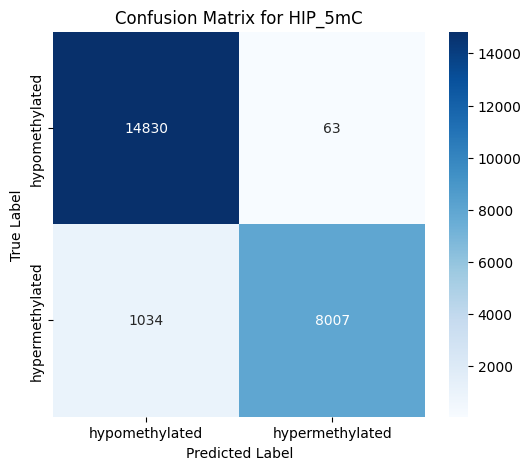

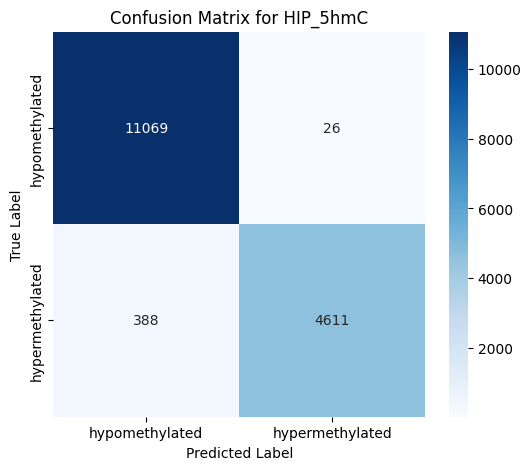

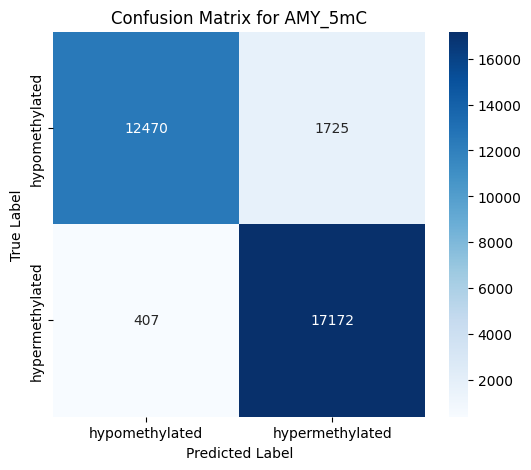

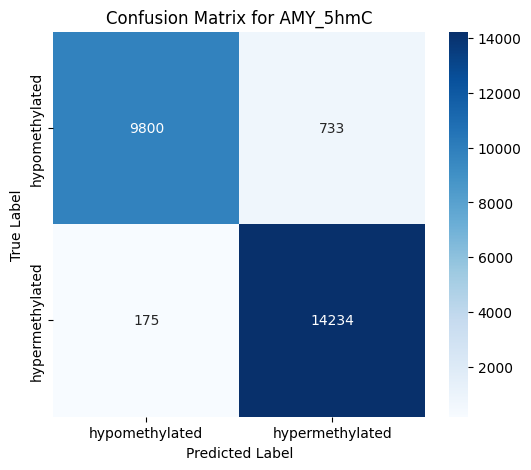

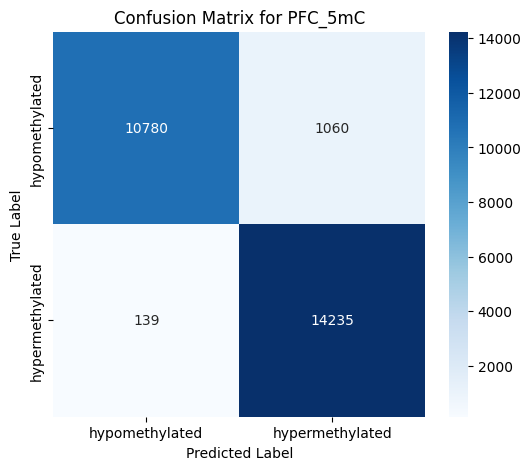

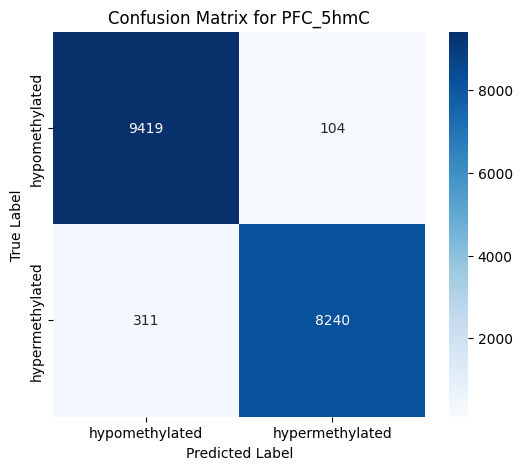

In [114]:
for key in pefromdict:
    print(f"Performance for {key}:")
    model = pefromdict[key]['model']
    X = pefromdict[key]['X']
    Y = pefromdict[key]['Y']
    y_pred_binary = pefromdict[key]['y_pred_binary']
    y = Y.ravel().astype(int)
    print("Accuracy:", accuracy_score(y, y_pred_binary))
    print("F1:", f1_score(y, y_pred_binary))
    print("\n")
    cm = confusion_matrix(Y, y_pred_binary)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['hypomethylated', 'hypermethylated'], yticklabels=['hypomethylated', 'hypermethylated'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {key}')

In [ ]:
import shap

for key in pefromdict:
    print(f"SHAP values for {key}:")
    model = pefromdict[key]['model']
    X_tmp = pefromdict[key]['X']
    explainer = shap.TreeExplainer(model,feature_names=['Astrocyte', 'Epen', 'GABA', 'Glut', 'Microglia', 'OPC', 'Oligo', 'Vascular'])
    shap_values = explainer.shap_values(X_tmp)
    pefromdict[key]['shap_values'] = shap_values
    pefromdict[key]['explainer'] = explainer

SHAP values for HIP_5mC:
SHAP values for HIP_5hmC:
SHAP values for AMY_5mC:
SHAP values for AMY_5hmC:
SHAP values for PFC_5mC:
SHAP values for PFC_5hmC:


In [138]:
shap_values_test = explainer(X_tmp)

In [141]:
pefromdict[key]

{'model': GradientBoostingClassifier(learning_rate=0.05, max_depth=10, n_estimators=200,
                            random_state=42),
 'X': array([[0.02042347, 0.87374952, 0.02710247, ..., 0.        , 0.00163907,
         0.        ],
        [0.        , 0.        , 0.41003387, ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.11487379, ..., 0.61552996, 0.        ,
         0.        ],
        ...,
        [0.46374807, 0.        , 0.        , ..., 0.        , 0.53625193,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]]),
 'Y': array([[1],
        [1],
        [0],
        ...,
        [0],
        [1],
        [1]]),
 'y_prob_oof': array([0.5855965 , 0.57811862, 0.49291448, ..., 0.77254065, 0.43618867,
        0.43474067]),
 'y_pred_oof': array([1, 1, 0, ..., 1, 0, 0]),
 'y_pred': arra

In [144]:
pefromdict[key]['X'][0],pefromdict[key]['Y'][0]

(array([0.02042347, 0.87374952, 0.02710247, 0.03951094, 0.03757454,
        0.        , 0.00163907, 0.        ]),
 array([1]))

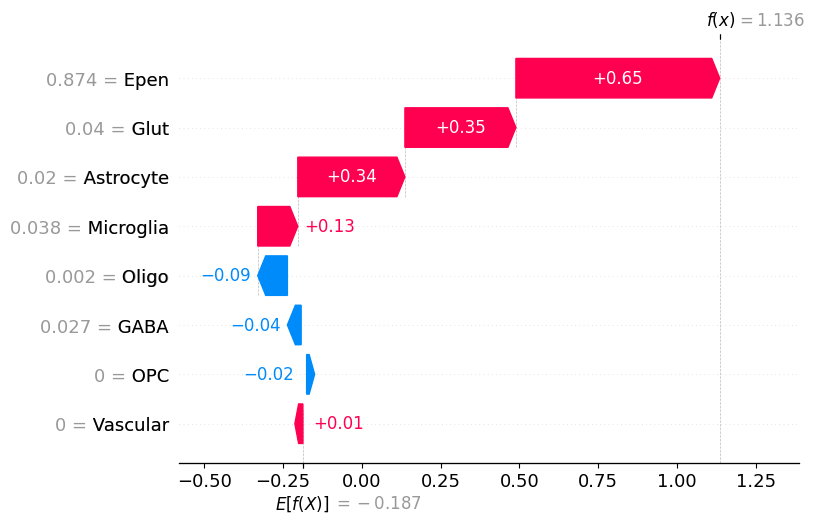

In [145]:
shap.plots.waterfall(shap_values_test[0])

In [ ]:
from sklearn.linear_model import Ridge
# uy

model = Ridge(alpha=1.0, positive=True)
model.fit(X, Y)

beta = model.coef_
y_pred = model.predict(X)

In [ ]:
from scipy.stats import pearsonr,spearmanr
r, p = pearsonr(Y.flatten(), y_pred.flatten())
r2, p2 = spearmanr(Y.flatten(), y_pred.flatten())


In [ ]:
Y.flatten()

In [ ]:
y_pred.flatten()

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import nnls
from sklearn.model_selection import cross_val_score

# 数据准备，X 和 Y 是已经准备好的数据
# X: 特征矩阵, Y: 目标值 (delta 5hmC/5mC 或其它)

# 模型训练
model_ridge = Ridge(alpha=1.0, positive=True)
model_ridge.fit(X, Y)

model_lasso = Lasso(alpha=0.01)
model_lasso.fit(X, Y)

model_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model_svr.fit(X, Y)


In [ ]:

#model_nnls = nnls(X, Y)

# 预测
ridge_pred = model_ridge.predict(X)
lasso_pred = model_lasso.predict(X)
svr_pred = model_svr.predict(X)
#nnls_pred = model_nnls[0] @ X.T  # NNLS 预测结果


In [ ]:
nnls_pred = svr_pred

In [ ]:

# 计算性能指标
mse_ridge = mean_squared_error(Y, ridge_pred)
r2_ridge = r2_score(Y, ridge_pred)

mse_nnls = mean_squared_error(Y, nnls_pred)
r2_nnls = r2_score(Y, nnls_pred)

mse_svr = mean_squared_error(Y, svr_pred)
r2_svr = r2_score(Y, svr_pred)

mse_lasso = mean_squared_error(Y, lasso_pred)
r2_lasso = r2_score(Y, lasso_pred)

print(f"Ridge MSE: {mse_ridge}, R²: {r2_ridge}")
print(f"NNLS MSE: {mse_nnls}, R²: {r2_nnls}")
print(f"SVR MSE: {mse_svr}, R²: {r2_svr}")
print(f"Lasso MSE: {mse_lasso}, R²: {r2_lasso}")

# 使用交叉验证
cv_ridge = cross_val_score(Ridge(alpha=1.0), X, Y, cv=5, scoring='neg_mean_squared_error')
print(f"Ridge CV MSE: {-cv_ridge.mean()}")

cv_svr = cross_val_score(SVR(kernel='rbf', C=1.0, epsilon=0.1), X, Y, cv=5, scoring='neg_mean_squared_error')
print(f"SVR CV MSE: {-cv_svr.mean()}")

cv_lasso = cross_val_score(Lasso(alpha=0.01), X, Y, cv=5, scoring='neg_mean_squared_error')
print(f"Lasso CV MSE: {-cv_lasso.mean()}")
